#### Three-mode coupled mode theory — OPO / Parametric Process

Extends the single-mode equation to three modes: pump (0), signal (+1), idler (−1),
coupled via the Kerr nonlinearity (four-wave mixing).

Equations of motion (all dimensionless, normalized to κ/2):

$$\frac{da_0}{d\tau} = -(1 + i\Delta_0)a_0 - i(|a_0|^2 + 2|a_1|^2 + 2|a_{-1}|^2)a_0 - 2i a_1 a_{-1} a_0^* + s$$

$$\frac{da_1}{d\tau} = -(1 + i\Delta_1)a_1 - i(|a_1|^2 + 2|a_0|^2 + 2|a_{-1}|^2)a_1 - i a_0^2 a_{-1}^*$$

$$\frac{da_{-1}}{d\tau} = -(1 + i\Delta_{-1})a_{-1} - i(|a_{-1}|^2 + 2|a_0|^2 + 2|a_1|^2)a_{-1} - i a_0^2 a_1^*$$

Nonlinear terms:
- **Self-phase modulation (SPM):** $-i|a_j|^2 a_j$ — each mode shifts its own resonance
- **Cross-phase modulation (XPM):** $-2i|a_k|^2 a_j$ — each mode shifts others (factor 2 vs SPM)
- **Four-wave mixing (FWM):** $-2i a_1 a_{-1} a_0^*$ (pump), $-i a_0^2 a_{-1}^*$ (signal), $-i a_0^2 a_1^*$ (idler) — parametric coupling that transfers energy from pump to signal/idler

Variables (all dimensionless, normalized to κ/2):
- $\tau = (\kappa/2)\, t$ — normalized time
- $a_j$ — normalized complex amplitude of mode $j$
- $\Delta_j$ — normalized detuning of mode $j$ (positive = blue-detuned)
- $s$ — normalized pump drive amplitude

Phase-matching: $\Delta_1 = \Delta_0 + \delta/2$, $\Delta_{-1} = \Delta_0 + \delta/2$,
where $\delta$ is the phase-matching offset (anomalous dispersion: $\delta < 0$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

sns.set_theme()

##### Equations of motion

In [ ]:
def cmt3(tau, state, Delta0, Delta1, Delta_1, s):
    """
    Right-hand side of the three-mode CMT equations.

    state : [Re(a0), Im(a0), Re(a1), Im(a1), Re(a_1), Im(a_1)]
      a0  : pump mode  (driven by s)
      a1  : signal mode
      a_1 : idler mode

    Delta0  : pump detuning  (swept during simulation)
    Delta1  : signal detuning = Delta0 + delta/2
    Delta_1 : idler detuning  = Delta0 + delta/2
    s       : real pump drive amplitude (s >= 0)
    """
    # Reconstruct complex amplitudes
    a0  = state[0] + 1j * state[1]
    a1  = state[2] + 1j * state[3]
    a_1 = state[4] + 1j * state[5]

    n0  = abs(a0)**2
    n1  = abs(a1)**2
    n_1 = abs(a_1)**2

    # Pump: SPM + XPM(signal) + XPM(idler) + FWM back-action
    da0  = (-(1 + 1j*Delta0)*a0
            - 1j*(n0 + 2*n1 + 2*n_1)*a0
            - 2j*a1*a_1*np.conj(a0)
            + s)

    # Signal: SPM + XPM(pump) + XPM(idler) + FWM gain
    da1  = (-(1 + 1j*Delta1)*a1
            - 1j*(n1 + 2*n0 + 2*n_1)*a1
            - 1j*a0**2*np.conj(a_1))

    # Idler: SPM + XPM(pump) + XPM(signal) + FWM gain
    da_1 = (-(1 + 1j*Delta_1)*a_1
            - 1j*(n_1 + 2*n0 + 2*n1)*a_1
            - 1j*a0**2*np.conj(a1))

    return [da0.real, da0.imag,
            da1.real, da1.imag,
            da_1.real, da_1.imag]

##### Detuning sweep

In [ ]:
def sweep3(s, Delta_range, delta=0.0, n_points=2000, tau_settle=50,
           seed_amplitude=1e-6):
    """
    Slowly scan pump detuning Delta0 across the resonance.
    Signal and idler detunings track as:
      Delta1  = Delta0 + delta/2
      Delta_1 = Delta0 + delta/2
    where delta is the phase-matching offset.
      delta = 0  : perfect phase matching (degenerate sidebands)
      delta < 0  : anomalous dispersion (lowers OPO threshold)
      delta > 0  : normal dispersion

    Returns:
        Deltas         : array of pump detuning values
        n0, n1, n_1   : intracavity photon numbers |a0|², |a1|², |a_1|²
        T              : transmission |s - a0|²
    """
    Deltas = np.linspace(Delta_range[0], Delta_range[1], n_points)
    n0  = np.zeros(n_points)
    n1  = np.zeros(n_points)
    n_1 = np.zeros(n_points)
    T   = np.zeros(n_points)

    # Start with empty cavity; tiny seed in signal/idler to allow OPO build-up
    state = [0.0, 0.0, seed_amplitude, 0.0, seed_amplitude, 0.0]

    for k, D0 in enumerate(Deltas):
        D1  = D0 + delta / 2
        D_1 = D0 + delta / 2

        sol = solve_ivp(
            fun     = lambda tau, y: cmt3(tau, y, D0, D1, D_1, s),
            t_span  = (0, tau_settle),
            y0      = state,
            method  = 'RK45',
            rtol    = 1e-8,
            atol    = 1e-10,
            dense_output = False,
        )
        state = sol.y[:, -1]   # use final state as IC for next step

        a0  = state[0] + 1j * state[1]
        a1  = state[2] + 1j * state[3]
        a_1 = state[4] + 1j * state[5]

        n0[k]  = abs(a0)**2
        n1[k]  = abs(a1)**2
        n_1[k] = abs(a_1)**2
        T[k]   = abs(s - a0)**2

    return Deltas, n0, n1, n_1, T

In [ ]:
# Drive amplitudes
drive_values = [1.5, 2.0]


# Scan blue-to-red (positive → negative detuning) and back
Delta_range_fwd = ( 5.0, -5.0)   # forward scan (blue→red)
Delta_range_bwd = (-5.0,  5.0)   # backward scan (red→blue), shows hysteresis

# Phase-matching offset (anomalous dispersion: delta < 0 lowers OPO threshold)
delta = -1.0

delta = 0

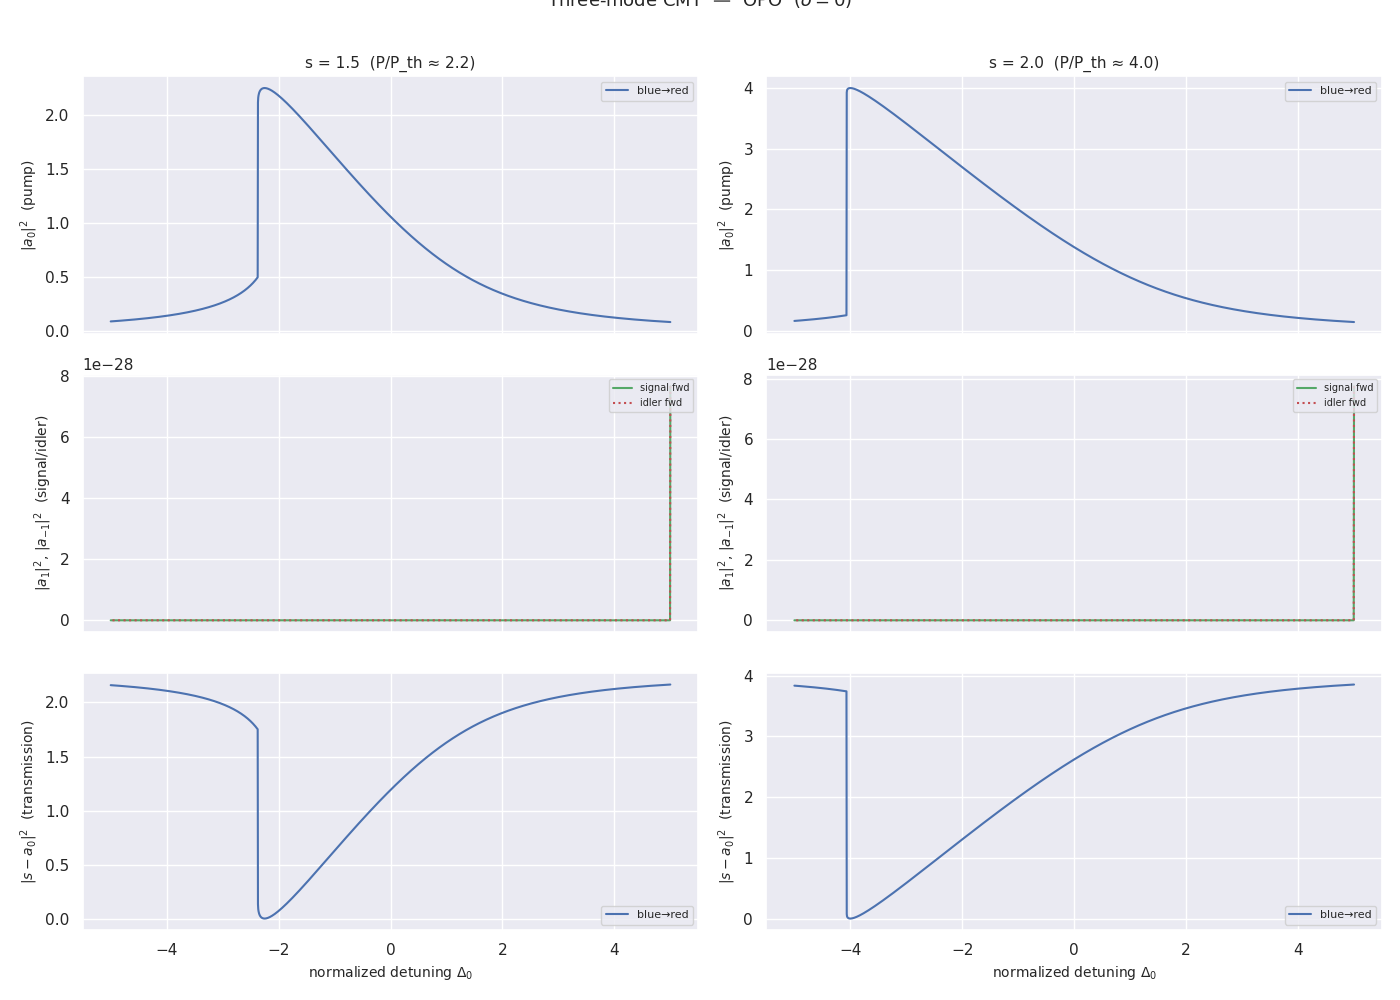

In [ ]:
%matplotlib widget

fig, axes = plt.subplots(3, len(drive_values), figsize=(14, 10), sharex=True)

for ind, s in enumerate(drive_values):
    D_fwd, n0f, n1f, n_1f, Tf = sweep3(s, Delta_range_fwd, delta=delta)
    # D_bwd, n0b, n1b, n_1b, Tb = sweep3(s, Delta_range_bwd, delta=delta)

    ax_pump = axes[0, ind]
    ax_si   = axes[1, ind]
    ax_T    = axes[2, ind]

    # --- Pump intracavity power ---
    ax_pump.plot(D_fwd, n0f, color='C0', lw=1.5, label='blue→red')
    # ax_pump.plot(D_bwd, n0b, color='C1', lw=1.5, ls='--', label='red→blue')
    ax_pump.set_title(f's = {s}  (P/P_th ≈ {s**2:.1f})', fontsize=11)
    ax_pump.set_ylabel(r'$|a_0|^2$  (pump)', fontsize=10)
    ax_pump.legend(loc=1, fontsize=8)

    # --- Signal & idler intracavity power ---
    ax_si.plot(D_fwd, n1f,  color='C2', lw=1.5, label='signal fwd')
    # ax_si.plot(D_bwd, n1b,  color='C2', lw=1.5, ls='--', label='signal bwd')
    ax_si.plot(D_fwd, n_1f, color='C3', lw=1.5, ls=':',  label='idler fwd')
    # ax_si.plot(D_bwd, n_1b, color='C3', lw=1.5, ls='-.', label='idler bwd')
    ax_si.set_ylabel(r'$|a_1|^2$, $|a_{-1}|^2$  (signal/idler)', fontsize=10)
    ax_si.legend(loc=1, fontsize=7)

    # --- Transmission ---
    ax_T.plot(D_fwd, Tf, color='C0', lw=1.5, label='blue→red')
    # ax_T.plot(D_bwd, Tb, color='C1', lw=1.5, ls='--', label='red→blue')
    ax_T.set_ylabel(r'$|s - a_0|^2$  (transmission)', fontsize=10)
    ax_T.set_xlabel(r'normalized detuning $\Delta_0$', fontsize=10)
    ax_T.legend(loc=4, fontsize=8)

fig.suptitle(rf'Three-mode CMT  —  OPO  ($\delta = {delta}$)', fontsize=13, y=1.01)
fig.tight_layout()
# fig.savefig("02_3mode_sweep.pdf", bbox_inches='tight')

##### OPO threshold curve: peak signal power vs drive amplitude

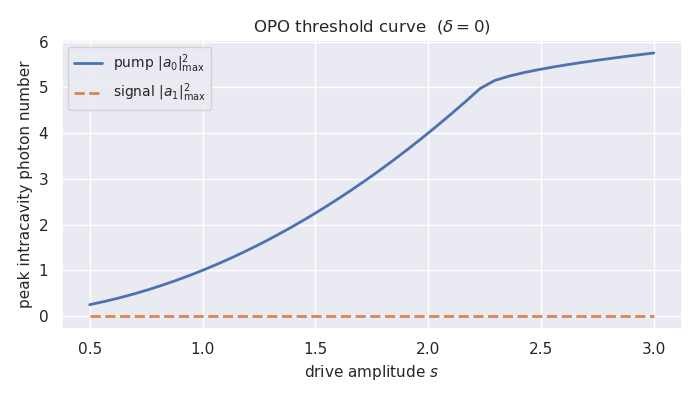

In [ ]:
s_values  = np.linspace(0.5, 3.0, 40)
peak_pump = np.zeros(len(s_values))
peak_sgnl = np.zeros(len(s_values))

for i, s in enumerate(s_values):
    _, n0f, n1f, _, _ = sweep3(s, Delta_range_fwd, delta=delta, n_points=500)
    peak_pump[i] = np.max(n0f)
    peak_sgnl[i] = np.max(n1f)

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(s_values, peak_pump, lw=2, label=r'pump $|a_0|^2_{\mathrm{max}}$')
ax2.plot(s_values, peak_sgnl, lw=2, ls='--', label=r'signal $|a_1|^2_{\mathrm{max}}$')
ax2.set_xlabel('drive amplitude $s$', fontsize=11)
ax2.set_ylabel('peak intracavity photon number', fontsize=11)
ax2.set_title(rf'OPO threshold curve  ($\delta = {delta}$)', fontsize=12)
ax2.legend(fontsize=10)
fig2.tight_layout()
# fig2.savefig("02_3mode_threshold.pdf")

##### Effect of dispersion: compare δ = 0, −1, −2

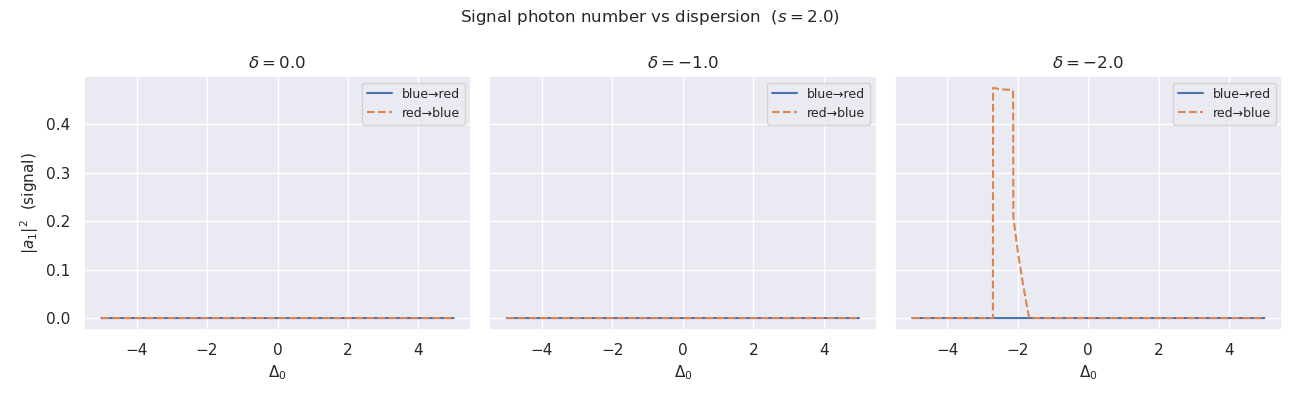

In [ ]:
s_fixed = 2.0
deltas  = [0.0, -1.0, -2.0]

fig3, axes3 = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, d in zip(axes3, deltas):
    D_fwd, _, n1f, _, _ = sweep3(s_fixed, Delta_range_fwd, delta=d)
    D_bwd, _, n1b, _, _ = sweep3(s_fixed, Delta_range_bwd, delta=d)

    ax.plot(D_fwd, n1f, color='C0', lw=1.5, label='blue→red')
    ax.plot(D_bwd, n1b, color='C1', lw=1.5, ls='--', label='red→blue')
    ax.set_title(rf'$\delta = {d}$', fontsize=12)
    ax.set_xlabel(r'$\Delta_0$', fontsize=11)
    ax.legend(fontsize=9)

axes3[0].set_ylabel(r'$|a_1|^2$  (signal)', fontsize=11)
fig3.suptitle(rf'Signal photon number vs dispersion  ($s = {s_fixed}$)', fontsize=12)
fig3.tight_layout()
# fig3.savefig("02_3mode_dispersion.pdf")

##### Steady-state analytic check (pump-only limit)

When signal and idler are negligible ($a_1 = a_{-1} = 0$), the pump
reduces to the single-mode equation. The steady-state condition is:

$$|a_0|^2 \left[1 + (\Delta_0 - |a_0|^2)^2\right] = s^2$$

We solve this numerically and overlay the roots on the pump scan (with $\delta = 0$)
to verify the pump equation is correct.

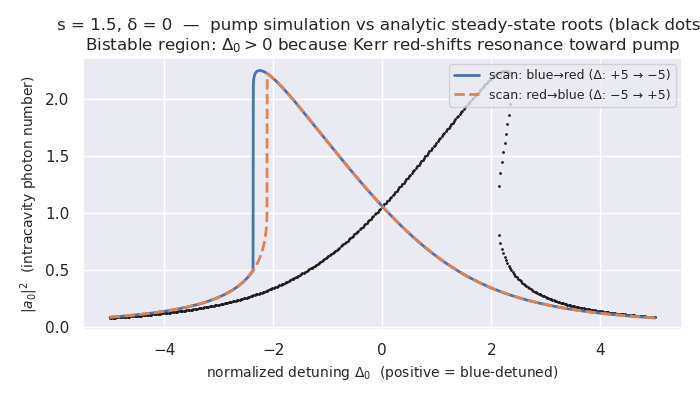

In [ ]:
s_check      = 1.5
Deltas_check = np.linspace(-5, 5, 400)

n_analytic = []
for D in Deltas_check:
    # Roots of: n³ - 2Δn² + (1 + Δ²)n - s² = 0,  where n = |a0|²
    coeffs = [1, -2*D, (1 + D**2), -s_check**2]
    roots  = np.roots(coeffs)
    real_positive = [r.real for r in roots if abs(r.imag) < 1e-9 and r.real >= 0]
    n_analytic.append(real_positive)

# Simulation with delta=0 so pump behaves like single-mode
D_fwd, n0f, _, _, _ = sweep3(s_check, (+5, -5), delta=0.0)
D_bwd, n0b, _, _, _ = sweep3(s_check, (-5, +5), delta=0.0)

fig4, ax4 = plt.subplots(figsize=(7, 4))

# Analytic roots
for k, D in enumerate(Deltas_check):
    for n_val in n_analytic[k]:
        ax4.plot(D, n_val, 'k.', ms=2)

ax4.plot(D_fwd, n0f, lw=2, label='scan: blue→red (Δ: +5 → −5)')
ax4.plot(D_bwd, n0b, lw=2, ls='--', label='scan: red→blue (Δ: −5 → +5)')

ax4.set_xlabel(r'normalized detuning $\Delta_0$  (positive = blue-detuned)', fontsize=10)
ax4.set_ylabel(r'$|a_0|^2$  (intracavity photon number)', fontsize=10)
ax4.set_title(
    f's = {s_check}, δ = 0  —  pump simulation vs analytic steady-state roots (black dots)\n'
    r'Bistable region: $\Delta_0 > 0$ because Kerr red-shifts resonance toward pump'
)
ax4.legend(loc=1, fontsize=9)

fig4.tight_layout()
# fig4.savefig("02_3mode_analytic_check.pdf")